# Exploratory Data Analysis and Visualisation

After data cleaning, Exploratory Data Analysis (EDA) and Visualisation are conducted to:

1. Understand the data: EDA helps to provide a comprehensive understanding of the data, including its structure, patterns, and relationships.

2. Identify patterns and relationships: it can also help to identify patterns and relationships between variables that may not be immediately apparent. This can help to generate hypotheses and guide further analysis. Most importantly, it enables us to identify good predictor variables for subsequent model building.

3. Communicate insights: Visualisation techniques can help to communicate data insights and present findings a clear and understandable way. This can help to facilitate decision-making and drive subsequent modeling action based on the data.

4. Select appropriate models: EDA and visualisation can help to identify which statistical models or machine learning algorithms may be appropriate for the data. This can help to ensure that the analysis is appropriate and accurate.

5. Validate assumptions: EDA and visualisation can help to validate assumptions about the data, such as those identified in our secondary research ealier. This can help to ensure that the analysis is appropriate and accurate.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
import sklearn
import plotly.express as px
import plotly.figure_factory as ff
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
bank_churn = pd.read_csv('Customer_Churn_Cleaned.csv')



In [3]:
print(bank_churn.columns)

Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited', 'Complain', 'Satisfaction_Score', 'Card_Type',
       'Point_Earned'],
      dtype='object')


In [4]:
# Categorical Variables
categorical = ["Exited", "Geography", "Gender", "NumOfProducts", "HasCrCard", "IsActiveMember", 
               "Complain", "Satisfaction_Score", "Card_Type"]

# Numerical Variables
numerical = ["CreditScore", "Age", "Tenure", "Balance", "EstimatedSalary", "Point_Earned"]

print("Categorical:", categorical)
print("Numerical:", numerical)

Categorical: ['Exited', 'Geography', 'Gender', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'Complain', 'Satisfaction_Score', 'Card_Type']
Numerical: ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary', 'Point_Earned']


In [5]:
bank_churn.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction_Score,Card_Type,Point_Earned
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


## EDA

In [6]:
bank_churn.dtypes 

CreditScore             int64
Geography              object
Gender                 object
Age                     int64
Tenure                  int64
Balance               float64
NumOfProducts           int64
HasCrCard               int64
IsActiveMember          int64
EstimatedSalary       float64
Exited                  int64
Complain                int64
Satisfaction_Score      int64
Card_Type              object
Point_Earned            int64
dtype: object

## Categorical Variables (Discrete, Non-continuous)

Geography – Represents the customer’s location (e.g., different countries or regions).

Gender – Encoded as numbers (1 = Male, 2 = Female), representing the gender of the customer.

NumOfProducts – The number of products that a customer has purchased from the bank.

HasCrCard – Indicates whether the customer owns a credit card (1 = Yes, 2 = No).

IsActiveMember – Whether the customer is an active member of the bank (1 = Yes, 2 = No).

Exited – Whether the customer has left the bank (1 = Yes, 2 = No).

Complain – Indicates whether the customer has filed a complaint (1 = Yes, 2 = No).

Satisfaction_Score – An ordinal score (1 to 5) given by customers based on their satisfaction with the bank’s services.

(Side Note: This is an ordinal variable, where the satisfaction score ranges from 1 to 5, 1 being the worst and 5 being the best.)

Card_Type – Represents the type of credit or debit card the customer holds.

(Side Note: This is an ordinal variable, where the card types include "Silver", "Gold", "Diamond", and "Platinum", ranked in that order.)

## Numerical Variables (Continuous or Discrete)

CreditScore – Represents the customer’s creditworthiness. A higher score usually means a lower likelihood of churn.

Age – The age of the customer, which may influence churn behavior (older customers are generally more loyal).

Tenure – The number of years the customer has been with the bank; longer tenure often indicates loyalty.

Balance – The customer’s account balance, which can influence their likelihood of leaving the bank.

EstimatedSalary – The estimated salary of the customer. Lower salaries may correlate with a higher likelihood of churn.

Point_Earned – The loyalty points accumulated by the customer for using bank services.

### Univariate Analysis


C:\Users\vedah\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


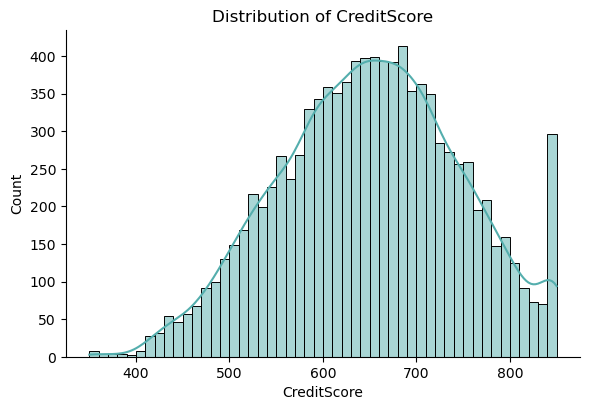

C:\Users\vedah\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


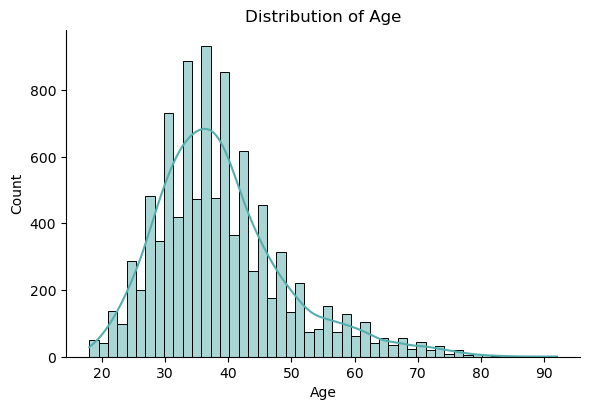

C:\Users\vedah\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


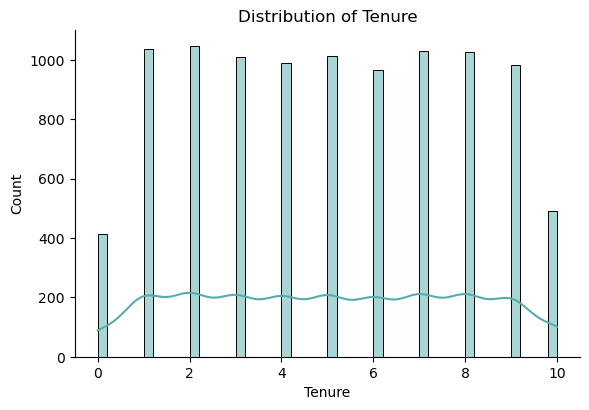

C:\Users\vedah\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


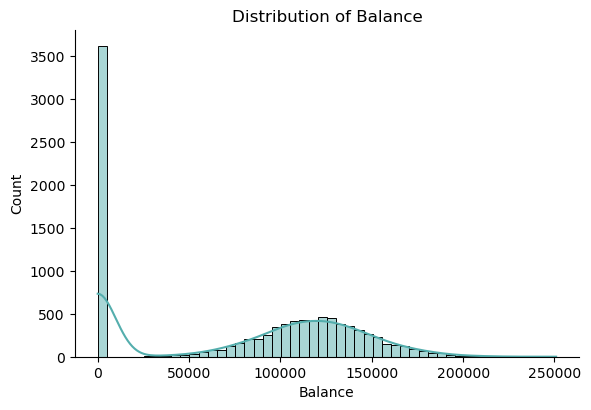

C:\Users\vedah\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


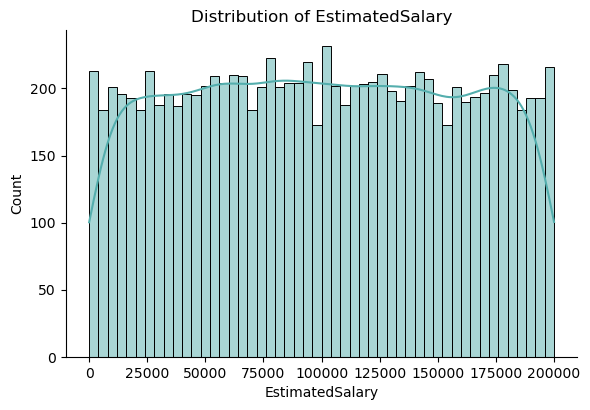

C:\Users\vedah\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


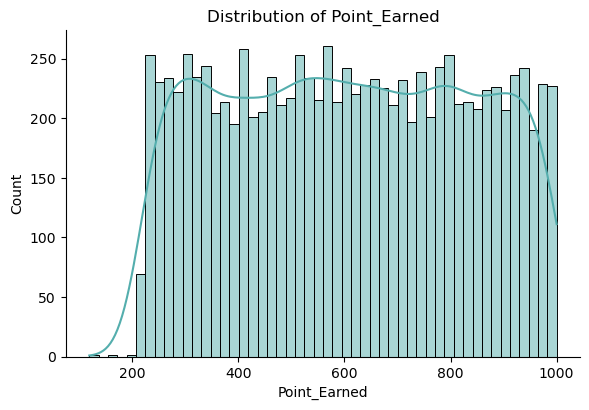

In [7]:
sb.set_palette('Spectral')

spectral = sb.color_palette('Spectral', 11)

# Distribution KDE Plot
for i in numerical:
    sb.displot(data=bank_churn, x=i, kde=True, bins=50, aspect=1.5, height=4, color=spectral[-2])
    plt.title(f'Distribution of {i}')
    plt.show()

In [8]:
df_cat = bank_churn.select_dtypes(include='object')
df_num = bank_churn.select_dtypes(exclude='object')

## Categorical Feature distribution

In [9]:
df_cat.nunique()


Geography    3
Gender       2
Card_Type    4
dtype: int64

In [10]:
def plots(df_cat):
    for col in df_cat.columns:
        plt.figure(figsize=(6,4))
        sns.countplot(x=col, data=df_cat, palette="pastel")
        plt.title(f"Count Plot for {col}")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.show()



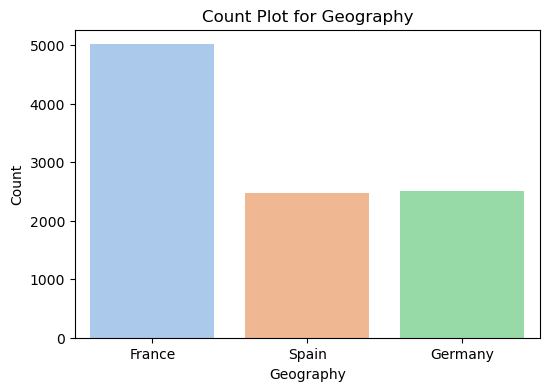

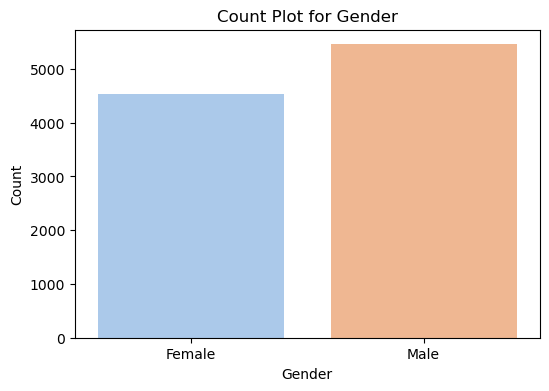

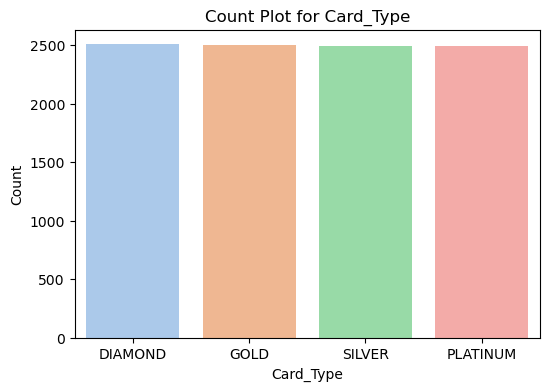

In [11]:
plots(df_cat)

1. The majority of the bank's customers are from France, with a total of 5,014 customers.  
2. Male customers outnumber female customers.  
3. Customer distribution across all four card types is relatively even.

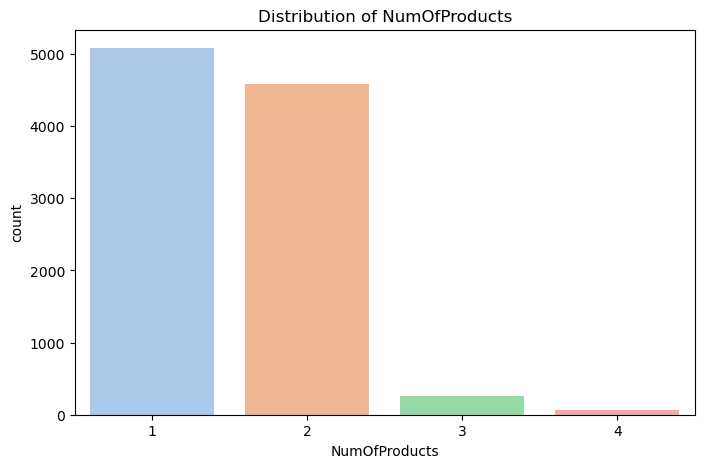

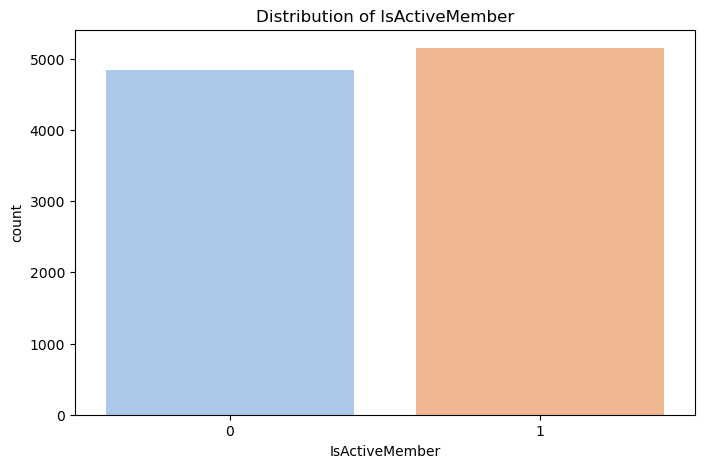

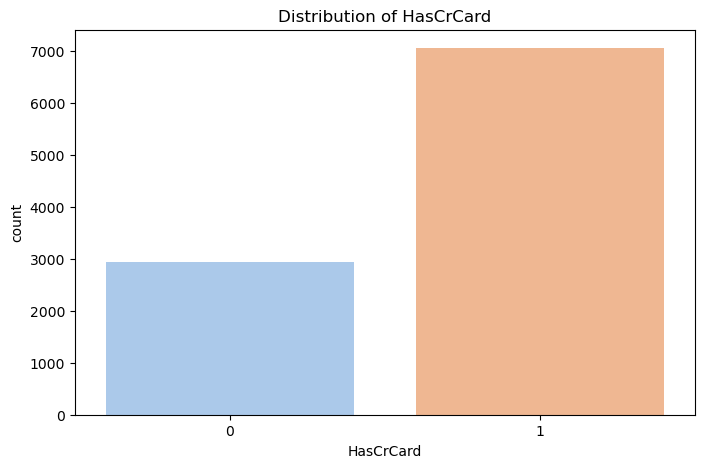

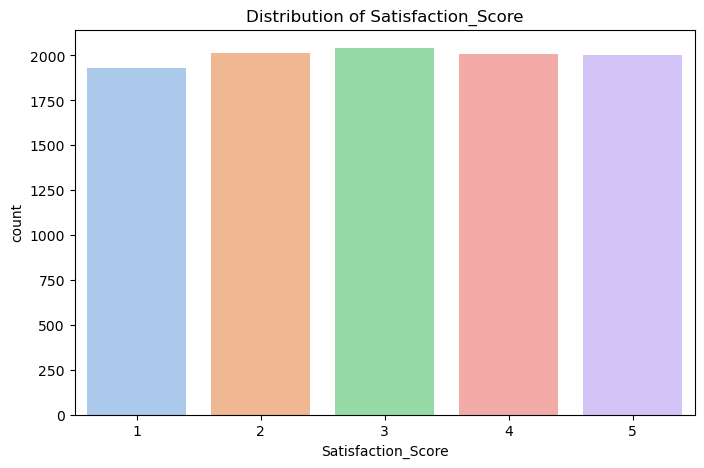

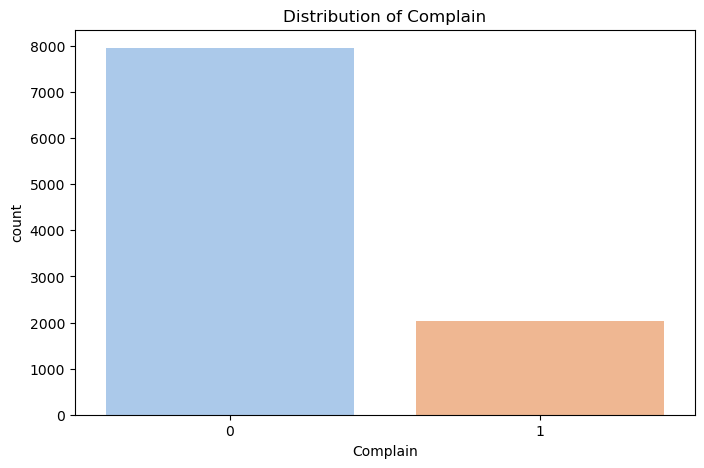

In [12]:
# Identify all categorical features
categorical_features = ["NumOfProducts", "IsActiveMember", "HasCrCard", "Satisfaction_Score", "Complain"]

# Iterate over categorical features and plot count plots
for feature in categorical_features:
    plt.figure(figsize=(8, 5))
    sns.countplot(data=bank_churn, x=feature, palette="pastel")
    plt.title(f"Distribution of {feature}")  # Moved inside the loop
    plt.show()  # Ensures each plot is displayed separately


## Bivariate Analysis


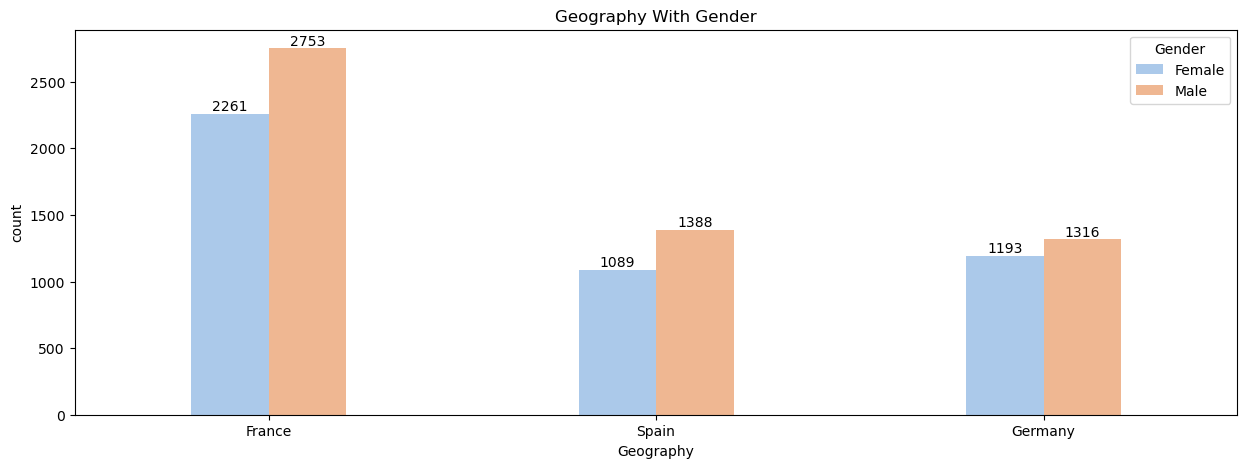

In [13]:
plt.figure(figsize=(15,5))
ax = sns.countplot(data=df_cat,x=df_cat['Geography'],width=0.4,hue='Gender',palette='pastel')
for label in ax.containers:
    ax.bar_label(label)
plt.title("Geography With Gender")
plt.show()

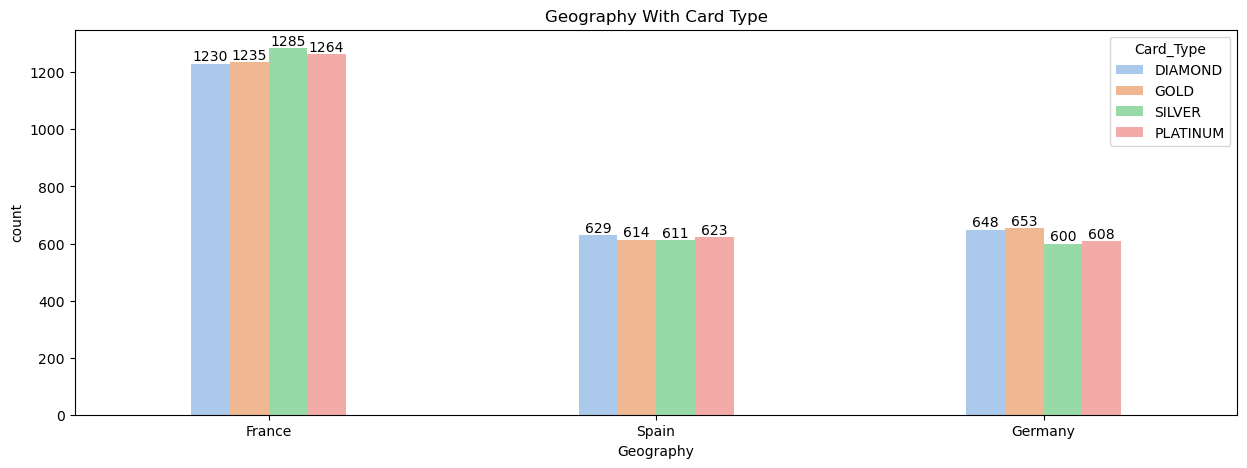

In [14]:
plt.figure(figsize=(15,5))
ax = sns.countplot(data=df_cat,x=df_cat['Geography'],width=0.4,hue='Card_Type',palette='pastel')
for label in ax.containers:
    ax.bar_label(label)
plt.title("Geography With Card Type")
plt.show()

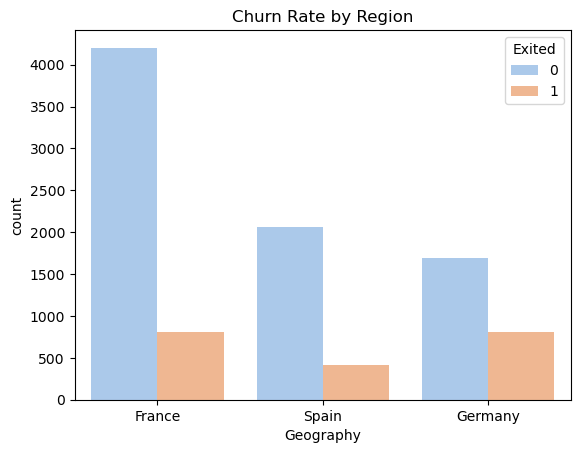

In [15]:
sns.countplot(data=bank_churn, x='Geography', hue='Exited', palette='pastel')
plt.title("Churn Rate by Region")
plt.show()

### Multivariate Analysis


C:\Users\vedah\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


<Figure size 1400x800 with 0 Axes>

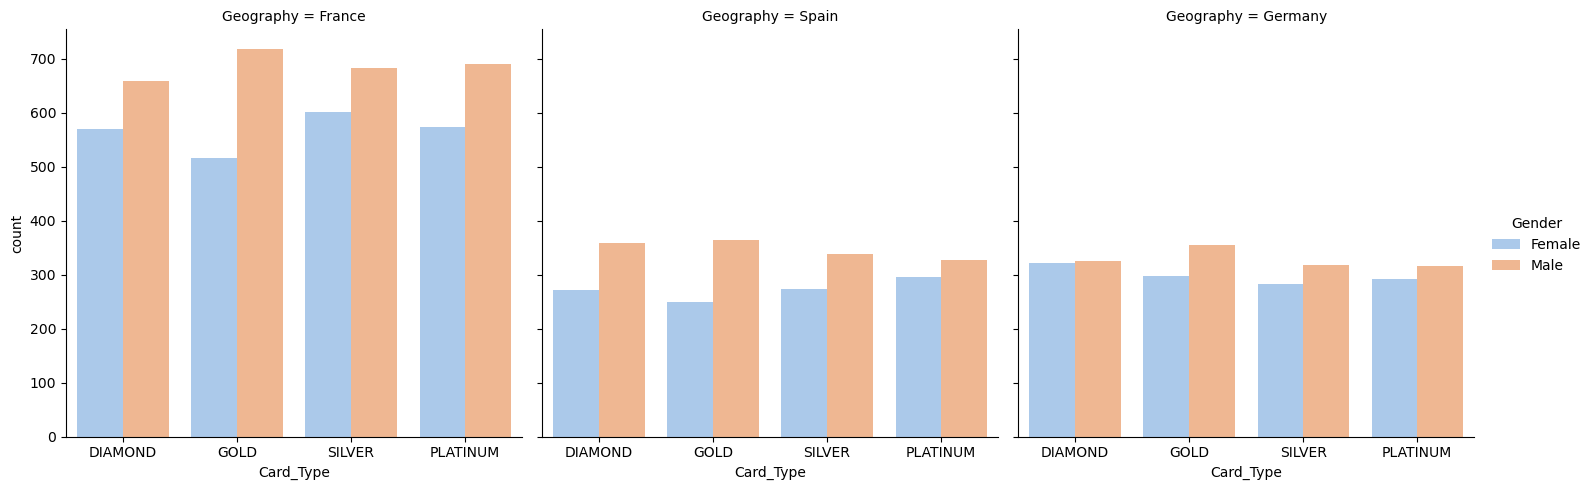

In [16]:
plt.figure(figsize=(14,8))
sns.catplot(data=bank_churn, x="Card_Type", hue="Gender", col="Geography", kind="count", palette="pastel")
plt.show()

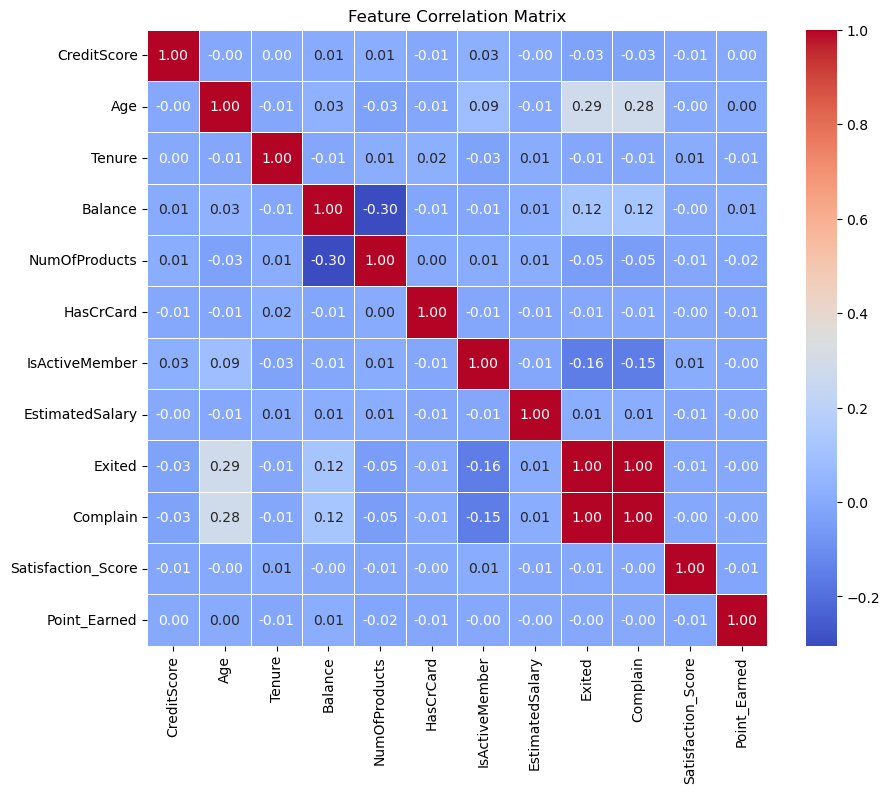

In [17]:
plt.figure(figsize=(10,8))
sns.heatmap(df_num.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Feature Correlation Matrix")
plt.show()

In [18]:
df_cat.nunique()


Geography    3
Gender       2
Card_Type    4
dtype: int64

# Categorical variables vs Churn

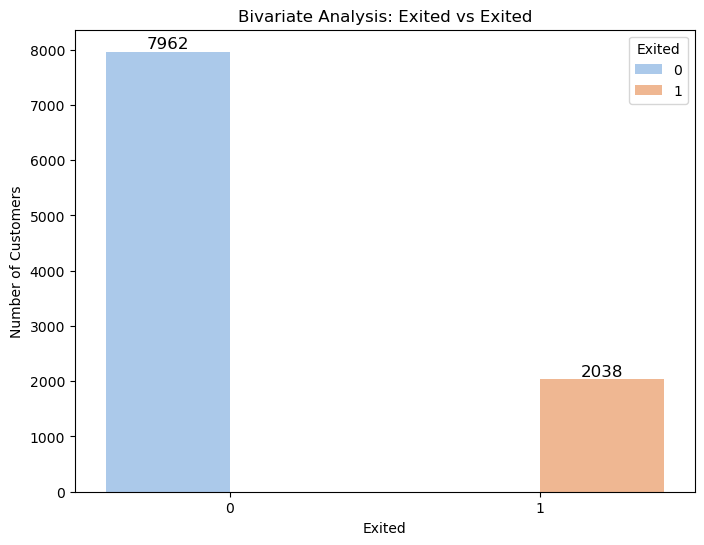

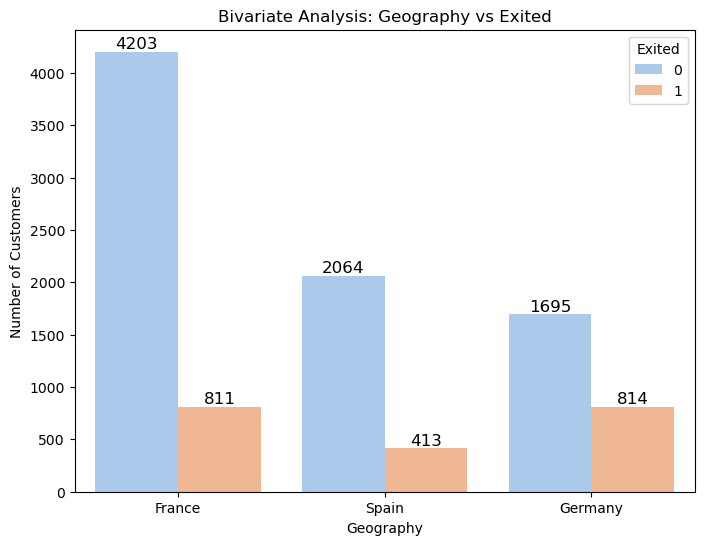

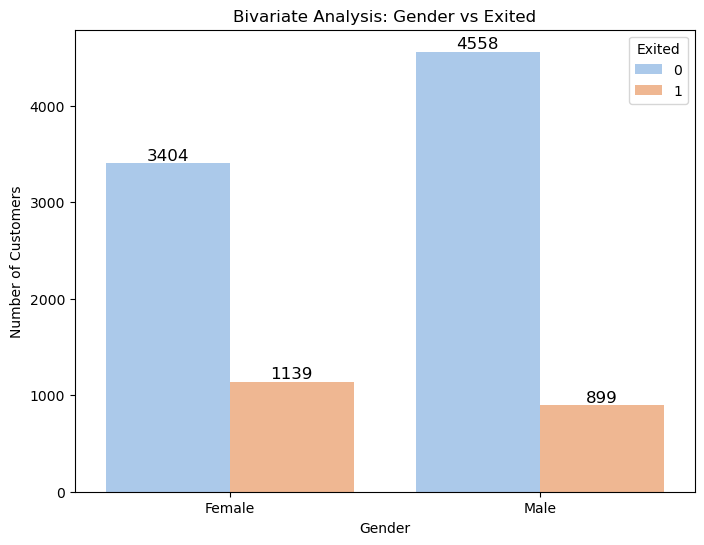

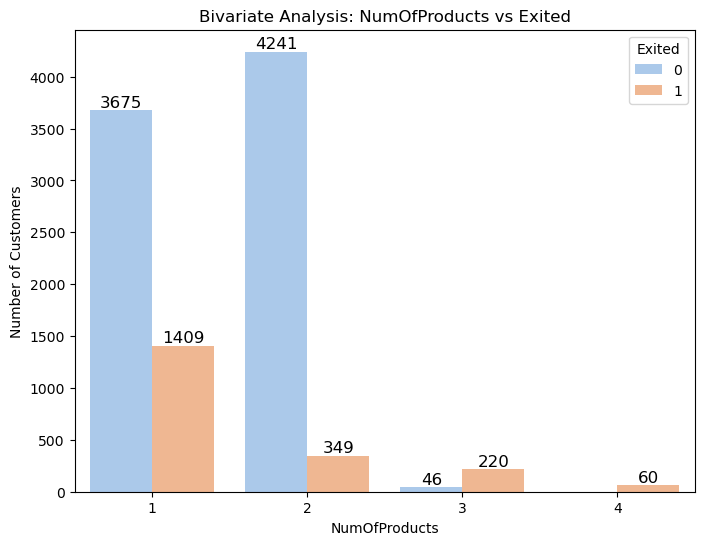

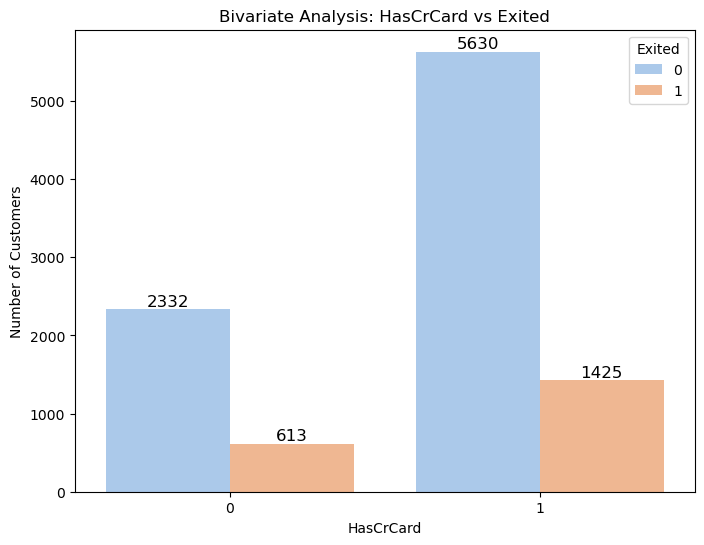

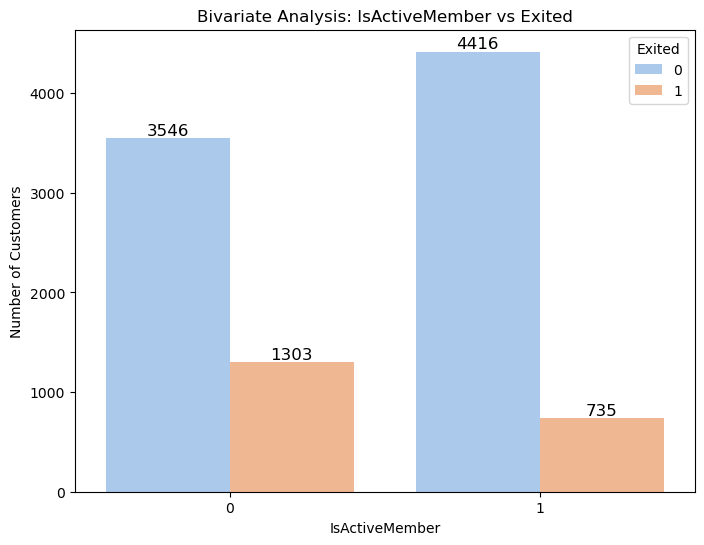

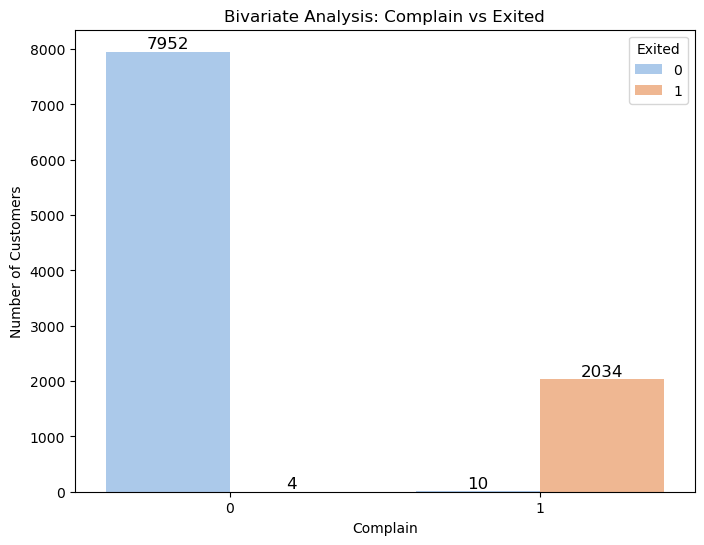

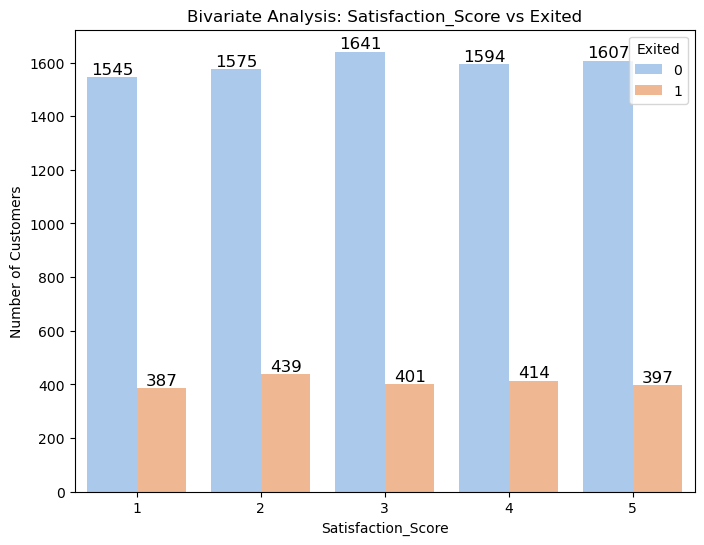

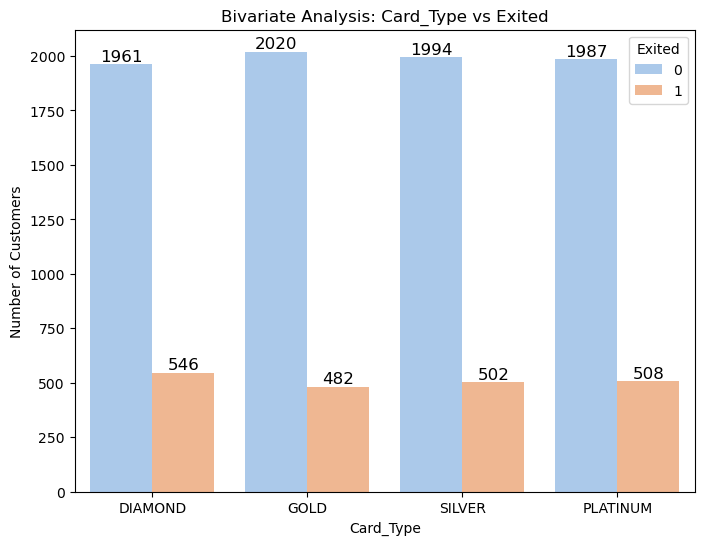

In [19]:
for col in categorical:
    plt.figure(figsize=(8, 6))
    ax = sns.countplot(x=col, hue="Exited", data=bank_churn, palette='pastel')

    # Add labels on top of the bars
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(f'{int(height)}', 
                        (p.get_x() + p.get_width() / 2., height), 
                        ha='center', va='bottom', fontsize=12, color='black')

    plt.title(f'Bivariate Analysis: {col} vs Exited')
    plt.xlabel(col)
    plt.ylabel("Number of Customers")
    plt.show()

## Numerical Varibles vs Churn

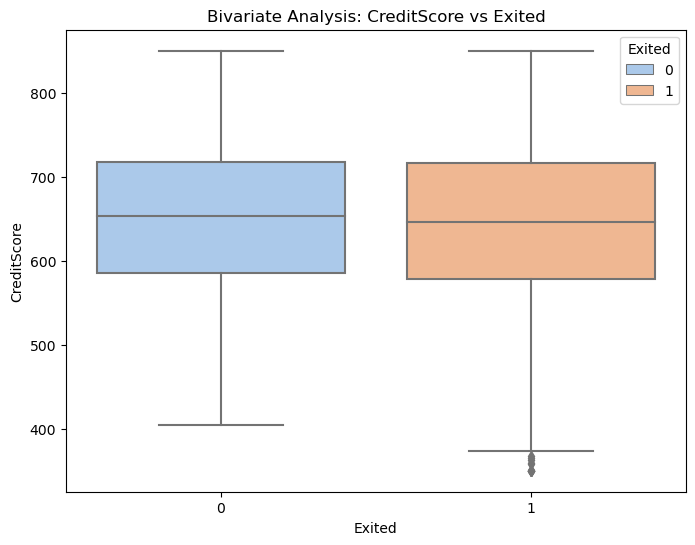

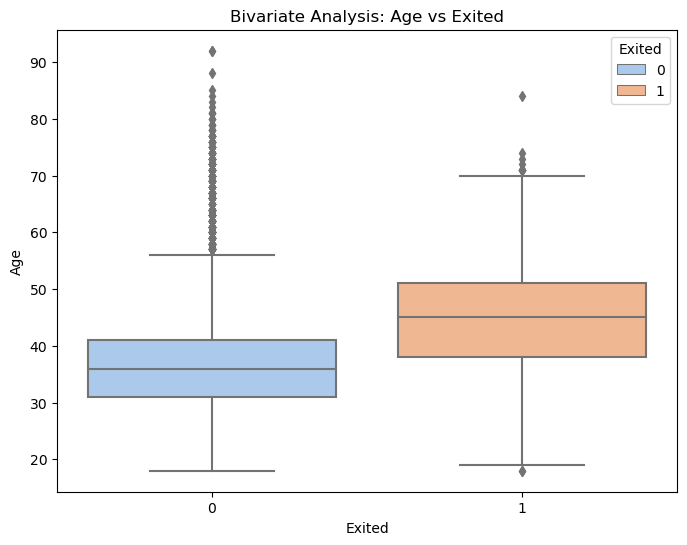

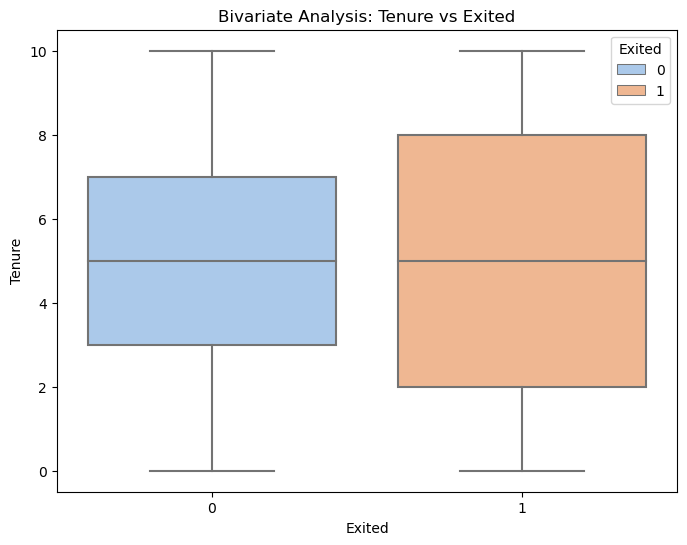

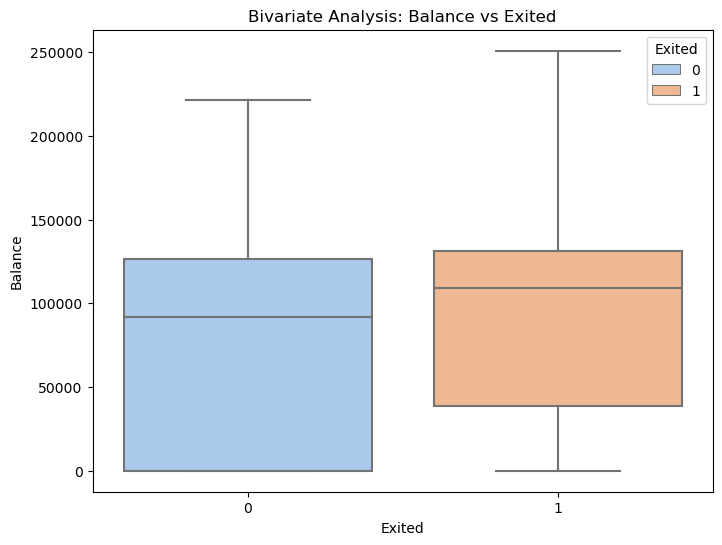

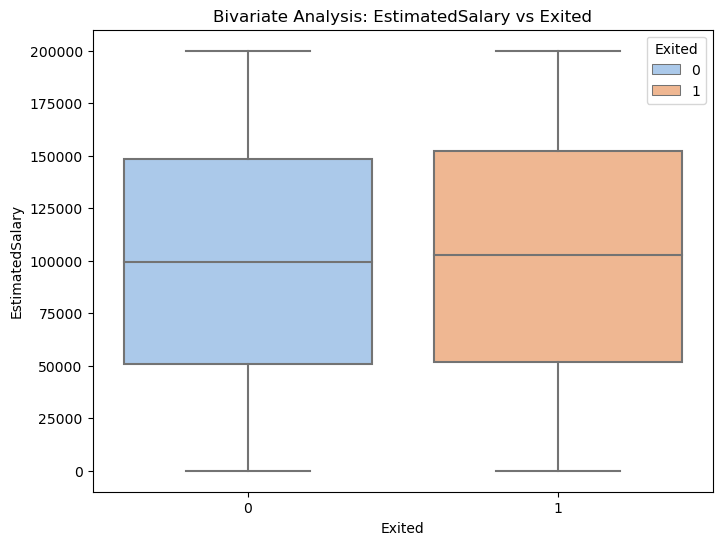

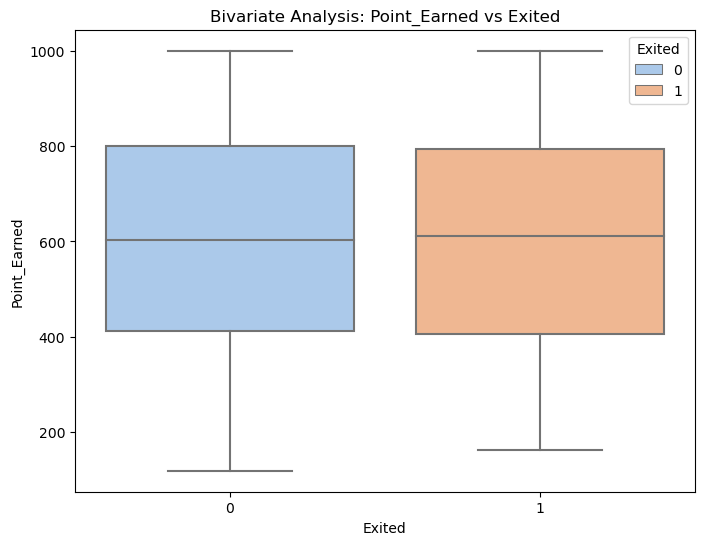

In [20]:
for col in numerical:
    plt.figure(figsize=(8, 6))
    sns.boxplot(x="Exited", y=col, data=bank_churn, hue="Exited", palette='pastel', dodge=False)
    plt.title(f'Bivariate Analysis: {col} vs Exited')
    plt.show()

# MULTIVARIATE

C:\Users\vedah\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


<Figure size 1400x800 with 0 Axes>

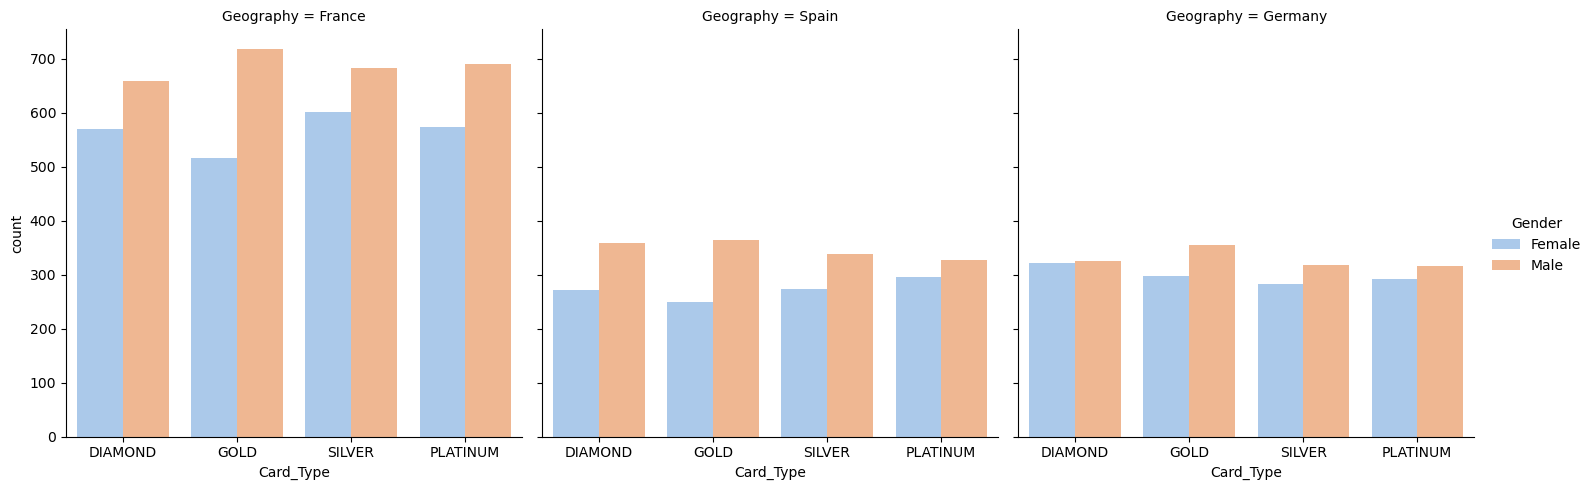

In [21]:
plt.figure(figsize=(14,8))
sns.catplot(data=bank_churn, x="Card_Type", hue="Gender", col="Geography", kind="count", palette="pastel")
plt.show()

## Balance vs Churn 

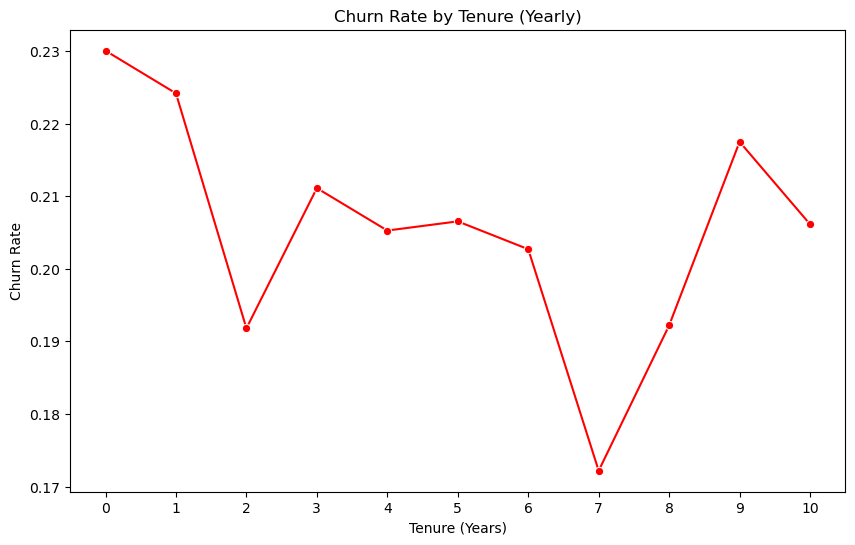

In [23]:
# Compute yearly churn rate
tenure_churn_rate = bank_churn.groupby("Tenure")["Exited"].mean()

# 🔹 Line Plot - Yearly Churn Rate
plt.figure(figsize=(10, 6))
sns.lineplot(x=tenure_churn_rate.index, y=tenure_churn_rate.values, marker="o", color="red")
plt.title("Churn Rate by Tenure (Yearly)")
plt.xlabel("Tenure (Years)")
plt.ylabel("Churn Rate")
plt.xticks(range(bank_churn["Tenure"].min(), bank_churn["Tenure"].max() + 1))  # Ensure every year is shown
plt.show()


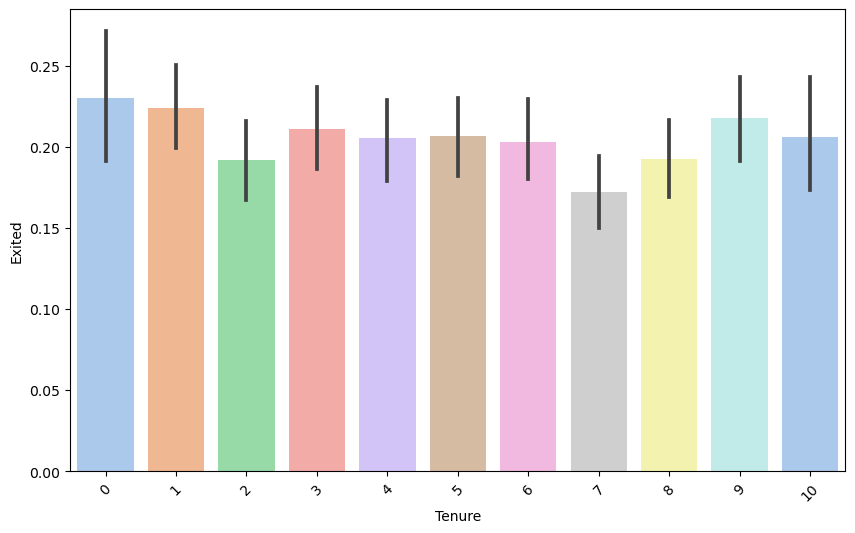

In [24]:
plt.figure(figsize=(10, 6))
sns.barplot(x=bank_churn["Tenure"], y=bank_churn["Exited"], palette="pastel")
plt.xticks(rotation=45)  # Rotate labels if needed
plt.show()

C:\Users\vedah\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


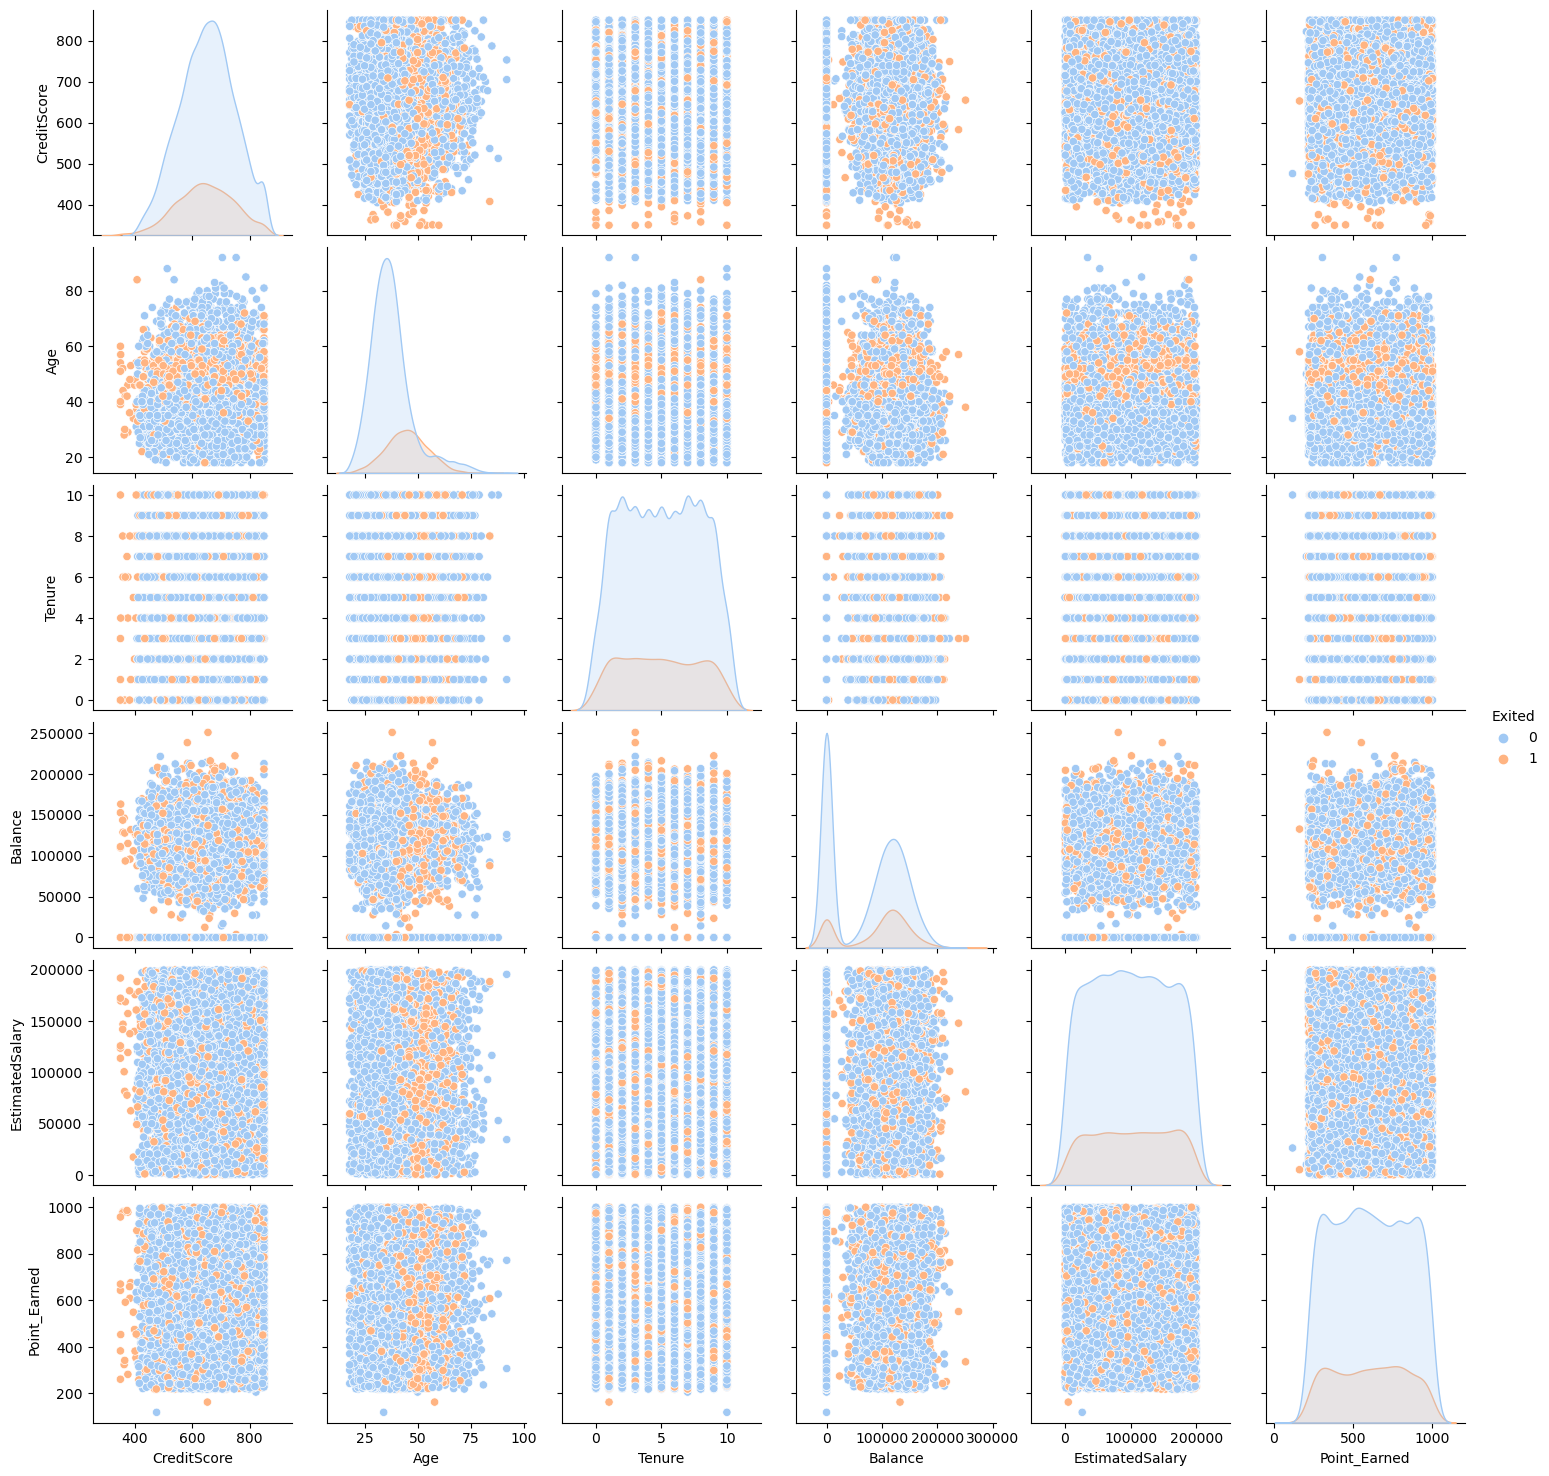

In [26]:
sns.pairplot(bank_churn[numerical + ['Exited']], hue='Exited', palette='pastel')


Text(0.5, 1.0, 'Churn Rate by Satisfaction Score')

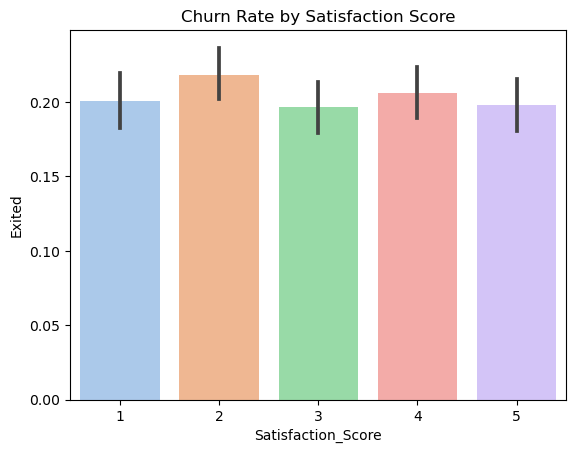

In [27]:
sns.barplot(x='Satisfaction_Score', y='Exited', data=bank_churn, palette='pastel')
plt.title("Churn Rate by Satisfaction Score")


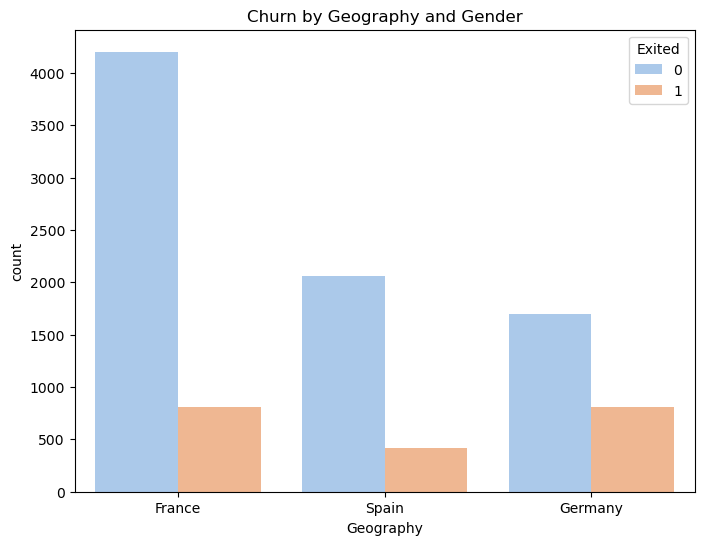

C:\Users\vedah\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


Text(0.5, 0.98, 'Churn by Geography and Gender')

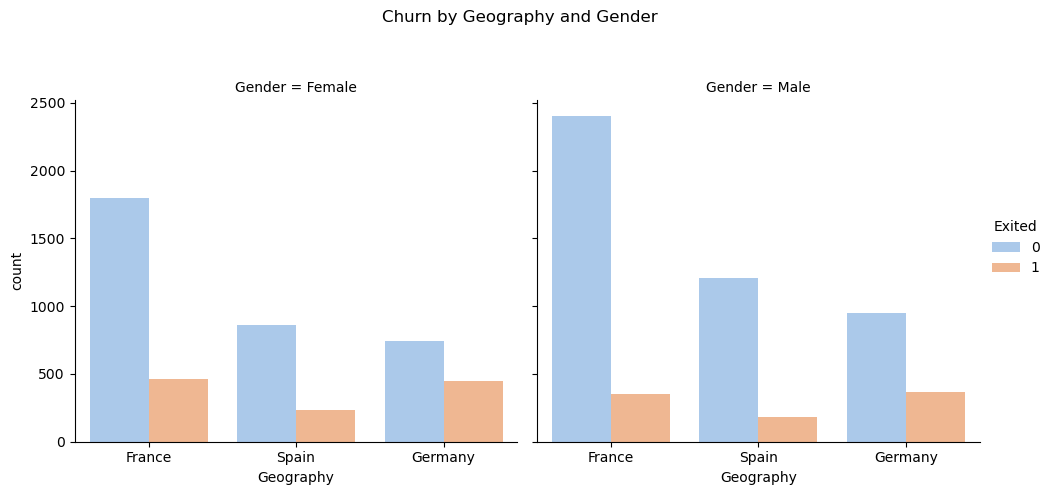

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.countplot(data=bank_churn, x='Geography', hue='Exited', palette='pastel', hue_order=[0, 1], dodge=True)
plt.title("Churn by Geography and Gender")
plt.show()
g = sns.catplot(data=bank_churn, x='Geography', hue='Exited', col='Gender', kind='count', palette='pastel')
g.set_titles("Gender = {col_name}")
g.fig.subplots_adjust(top=0.8)
g.fig.suptitle("Churn by Geography and Gender")
